In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 'Images', '1680258206248IK0CEHYZB9.pdf', 'ITDe-Filing-2022 Setup 1.1.19.exe.blockmap', 'latest.json', 'title.pdf', 'FORM AY 21-22.pdf', 'ALKPM8697A_upload_2022-23_31-03-2023-15-10.json', 'ABS-20230204T160945Z-001', 'rank_card_507659.pdf', 'application_507659.pdf', 'allotment_507659.pdf', 'IMG_20230809_185257.jpg', 'Classroom', 'Date of birth.pdf', 'Rank card.pdf', 'Screenshot_2023-10-04-19-32-37-319_cn (1).wps.moffice_eng.pdf', 'Screenshot_2023-10-04-19-32-37-319_cn.wps.moffice_eng.pdf', 'IMG_20231004_200415.pdf', 'img20230103_13521852.jpg', 'ALLOTMENT CARD .pdf', 'DOB.pdf', 'CLASS 12.pdf', 'DOMICILE.pdf', 'SAVE_20231121_123535.jpg', 'FINAL ANTI RAG 2.pdf', 'Screenshot_2023-12-13-20-02-03-104_com.google.android.apps.nbu.paisa.user.jpg', 'Screenshot_2024-03-04-17-48-58-125_com.google.android.apps.nbu.paisa.user.jpg', 'Screenshot_2024-04-25-13-25-11-625_com.google.android.apps.nbu.paisa.user.jpg', 'Screenshot_2024-08-16-23-10-43-110_com.google.a

In [4]:
import os

zip_path = '/content/drive/MyDrive/archive (2).zip'

print(os.path.exists(zip_path))

True


In [5]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive (2).zip'
extract_path = '/content/cats_dogs'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [16]:
# library
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [17]:
# generators (divide the data into batches)
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/cats_dogs/train',
    labels = 'inferred',
    label_mode = 'int', # cat asiign 0 dog assign 1
    batch_size = 32,
    image_size = (256,256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/cats_dogs/test',
    labels = 'inferred',
    label_mode = 'int', # cat asiign 0 dog assign 1
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [18]:
# images stored in numpy array format problem is numpy array each value is 0-255 so we need to chnage it into 0-1
# Normalize

def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process) # what map does - eta each time train_ds theke image nebe ar process ke debe and done transformation so each pixel value is between 0-1
validation_ds = validation_ds.map(process)


In [19]:
# cnn model

# 3 - convolution layers

model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3), padding = 'valid', activation = 'relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(64,kernel_size=(3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(128,kernel_size=(3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding = 'valid'))

model.add(Flatten())

model.add(Dense(128,activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
#compile the model
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])


In [22]:
# model run
history = model.fit(train_ds, epochs=10, validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accuracy: 0.5933 - loss: 1.2954 - val_accuracy: 0.6220 - val_loss: 0.6538
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7053 - loss: 0.5709 - val_accuracy: 0.6906 - val_loss: 0.5543
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7650 - loss: 0.4864 - val_accuracy: 0.7866 - val_loss: 0.4743
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.8059 - loss: 0.4261 - val_accuracy: 0.7450 - val_loss: 0.5066
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.8417 - loss: 0.3632 - val_accuracy: 0.5430 - val_loss: 1.0063
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.8786 - loss: 0.2883 - val_accuracy: 0.7786 - val_loss: 0.4827
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.9220 - loss: 0.1953 - val_accuracy: 0.7740 - val_loss: 0.5917
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9505 - loss: 0.1385 - 

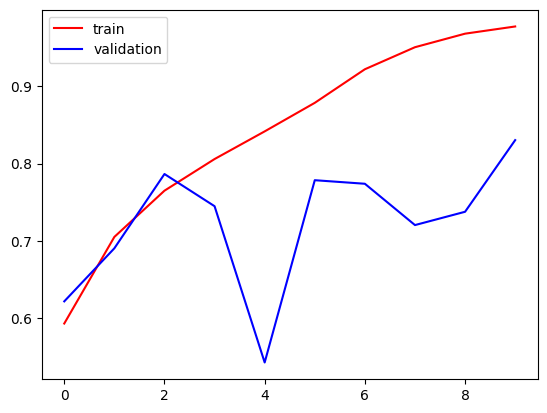

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color ='red', label = 'train')
plt.plot(history.history['val_accuracy'], color ='blue', label = 'validation')
plt.legend()
plt.show()



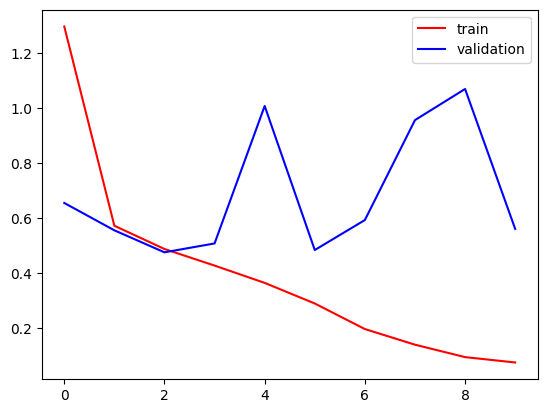

In [24]:
plt.plot(history.history['loss'], color ='red', label = 'train')
plt.plot(history.history['val_loss'], color ='blue', label = 'validation')
plt.legend()
plt.show()

In [15]:
# ways to reduce overfitting

# add more data
# data augmentation
# l1/l2 regularizer
# dropout
# batch normalization
# reduce complexity

In [25]:
from google.colab import files

uploaded = files.upload()

Saving cat2.jpg to cat2.jpg
Saving dog2.jpg to dog2.jpg
Saving dog1.jpg to dog1.jpg
Saving cat1.jpg to cat1.jpg


In [26]:
import os

print(os.listdir('/content'))

['.config', 'dog1.jpg', 'dog2.jpg', 'cat2.jpg', 'cat1.jpg', 'drive', 'cats_dogs', 'sample_data']


In [27]:
import cv2

In [45]:
test_img = cv2.imread('/content/dog1.jpg')

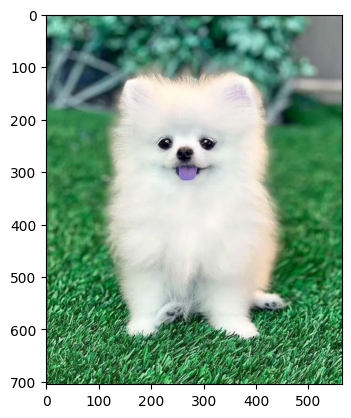

In [46]:
plt.imshow(test_img)

In [47]:
test_img.shape

(705, 564, 3)

In [48]:
test_img = cv2.resize(test_img,(256,256))

In [49]:
test_input = test_img.reshape((1,256,256,3))

In [50]:
# model.predict(test_input)

In [51]:
import os

print(os.listdir('/content/cats_dogs/train'))

['cats', 'dogs']


In [52]:
prediction = model.predict(test_input)[0][0]

print("Prediction score:", prediction)

if prediction < 0.5:
    print("🐱 Cat")
    print("Confidence:", (1 - prediction) * 100, "%")
else:
    print("🐶 Dog")
    print("Confidence:", prediction * 100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction score: 0.0
🐱 Cat
Confidence: 100.0 %
